<h2 style="color:#08519c; margin-bottom:0;">4. Exploratory Data Analysis (EDA)</h2>
<hr style="border:2px solid #08519c; margin-top:4px; margin-bottom:12px;">

Now that preprocessing is complete, we can:
- Explore distributions of key variables (experience, skills, certifications, salary).  
- Identify correlations between predictors and salary outcomes.  
- Spot patterns and anomalies across industries, company sizes, and education levels.    

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data_cleaned = pd.read_csv("data_cleaned.csv")

#### <span style="color:#08519c">4.1 Statistical Summaries</span>

##### <font color='#0891b2'> Salary Summary

In [3]:
salary_summary = data_cleaned['salary'].describe().round(2).to_frame().rename(columns={'salary':'Salary'})
salary_summary

,Salary
count,250000.00
mean,145718.08
std,37407.95
min,31867.00
25%,119358.00
50%,143453.00
75%,169492.00
max,333046.00


##### <font color='#0891b2'> Experience Summary

In [4]:
experience_summary = data_cleaned['experience_years'].describe().round(2).to_frame().rename(columns={'experience_years':'Experience (Years)'})
experience_summary

,Experience (Years)
count,250000.00
mean,10.01
std,6.06
min,0.00
25%,5.00
50%,10.00
75%,15.00
max,20.00


##### <font color='#0891b2'>  Certifications Summary

In [5]:
cert_summary = data_cleaned['certifications'].describe().round(2).to_frame().rename(columns={'certifications':'Certifications'})
cert_summary

,Certifications
count,250000.00
mean,2.49
std,1.71
min,0.00
25%,1.00
50%,2.00
75%,4.00
max,5.00


#### 📊 Summary of Statistical Summaries
- **Salary:** Avg ≈ 145.7k, range 31.8k–333k, moderate spread  
- **Experience:** Avg ≈ 10 years, balanced distribution (0–20)  
- **Certifications:** Avg ≈ 2.5, most hold 1–4  

#### <span style="color:#08519c">4.2 Univariate Analysis</span>

##### <font color='#0891b2'>  Job Title Counts

In [6]:
job_title_counts = data_cleaned['job_title'].value_counts().to_frame().rename(columns={'job_title':'Count'})
job_title_counts

,count
job_title,
Backend Developer,21125
Cybersecurity Analyst,20959
Product Manager,20950
AI Engineer,20945
Data Scientist,20890
DevOps Engineer,20889
Software Engineer,20876
Data Analyst,20722
Cloud Engineer,20686


In [7]:
print("Most common job title:", data_cleaned['job_title'].mode()[0])

Most common job title: Backend Developer


##### <font color='#0891b2'> Education Level Counts

In [8]:
edu_counts = data_cleaned['education_level'].value_counts().to_frame().rename(columns={'education_level':'Count'})
edu_counts

,count
education_level,
Master,50369
High School,50062
Bachelor,49942
PhD,49855
Diploma,49772


In [9]:
print("Most common education level:", data_cleaned['education_level'].mode()[0])

Most common education level: Master


##### <font color='#0891b2'> Company Size Counts

In [10]:
company_counts = data_cleaned['company_size'].value_counts().to_frame().rename(columns={'company_size':'Count'})
company_counts

,count
company_size,
Large,50253
Small,50243
Medium,50022
Enterprise,49874
Startup,49608


##### <font color='#0891b2'>  Industry Counts

In [11]:
industry_counts = data_cleaned['industry'].value_counts().to_frame().rename(columns={'industry':'Count'})
industry_counts

,count
industry,
Finance,25397
Consulting,25258
Media,25034
Manufacturing,25024
Technology,24903
Government,24900
Healthcare,24897
Education,24887
Telecom,24859


##### <font color='#0891b2'>  Remote Work Counts

In [12]:
remote_counts = data_cleaned['remote_work'].value_counts().to_frame().rename(columns={'work_mode':'Count'})
remote_counts

,count
remote_work,
No,83623
Hybrid,83476
Yes,82901


##### <font color='#0891b2'>  Skewness & kurtosis

In [13]:
skewness_kurtosis = pd.DataFrame({
    "Metric": ["Skewness", "Kurtosis"],
    "Salary": [data_cleaned['salary'].skew().round(2), data_cleaned['salary'].kurt().round(2)],
})
skewness_kurtosis

,Metric,Salary
0,Skewness,0.38
1,Kurtosis,0.15


#### 📊 Summary of Univariate Analysis
- **Job Titles:** Balanced distribution across roles; top counts include  
  Backend Developer (21,125), Cybersecurity Analyst (20,959), Product Manager (20,950),  
  AI Engineer (20,945), and Data Scientist (20,890).  
- **Education Levels:** Even spread — Master (50,369), High School (50,062), Bachelor (49,942), PhD (49,855), Diploma (49,772).  
- **Company Size:** Nearly equal representation — Large (50,253), Small (50,243), Medium (50,022), Enterprise (49,874), Startup (49,608).  
- **Industry:** Broad coverage — Finance (25,397), Consulting (25,258), Media (25,034), Manufacturing (25,024), Technology (24,903), Government (24,900), Healthcare (24,897), Education (24,887), Telecom (24,859), Retail (24,841).  
- **Remote Work:** Well balanced — No (83,623), Hybrid (83,476), Yes (82,901).  
- **Salary Distribution:** Skewness ≈ 0.38 (slightly right‑skewed), Kurtosis ≈ 0.15 (near normal).  

#### <span style="color:#08519c">4.3 Bivariate Analysis</span>

##### <font color='#0891b2'> Salary by Location

In [14]:
location_salary = (
    data_cleaned.groupby('location', observed=True)['salary']
    .mean()
    .round(2)
    .reset_index())
location_salary

,location,salary
0,Australia,139359.64
1,Canada,167392.81
2,Germany,153376.90
3,India,97689.44
4,Netherlands,139296.33
5,Remote,139442.53
6,Singapore,139341.52
7,Sweden,139439.60
8,UK,160075.14
9,USA,181716.30


##### <font color='#0891b2'> Salary vs Experience

In [15]:
exp_salary = data_cleaned.groupby('experience_years')['salary'].mean().round(2).reset_index()


exp_salary.columns = ['Experience (Years)', 'Average Salary']

exp_salary

,Experience (Years),Average Salary
0,0,118872.62
1,1,121250.53
2,2,124228.94
3,3,126921.60
4,4,129688.78
5,5,131789.42
6,6,134900.10
7,7,137560.81
8,8,140667.76
9,9,142763.83


##### <font color='#0891b2'> Salary by Education

In [16]:
edu_salary = (
    data_cleaned.groupby('education_level', observed=True)['salary']
    .mean()
    .round(2)
    .reset_index()
)
edu_salary.columns = ['Education Level', 'Average Salary']
edu_salary

,Education Level,Average Salary
0,Bachelor,142410.66
1,Diploma,137160.31
2,High School,131715.56
3,Master,153299.45
4,PhD,163975.93


##### <font color='#0891b2'>Salary by Job Title

In [17]:
job_salary = (
    data_cleaned.groupby('job_title', observed=True)['salary']
    .mean()
    .round(2)
    .reset_index()
)
job_salary.columns = ['Job Title', 'Average Salary']
job_salary

,Job Title,Average Salary
0,AI Engineer,173498.48
1,Backend Developer,139202.77
2,Business Analyst,122551.23
3,Cloud Engineer,152102.54
4,Cybersecurity Analyst,148697.70
5,Data Analyst,119891.70
6,Data Scientist,147258.21
7,DevOps Engineer,149959.27
8,Frontend Developer,132653.84
9,Machine Learning Engineer,163022.50


##### <font color='#0891b2'>Work mode vs. Salary

In [18]:
workmode_salary = (
    data_cleaned.groupby('work_mode', observed=True)['salary']
    .mean()
    .round(2)
    .reset_index())

workmode_salary.columns = ['Work Mode', 'Average Salary']

workmode_salary

,Work Mode,Average Salary
0,Hybrid,143969.90
1,On-Site,143932.98
2,Remote,149279.03


#### 📊 Summary of Bivariate Analysis
- **Salary by Location:** USA highest (≈182k), Canada (≈167k), UK (≈160k). India lowest (~97k). Other regions cluster ~139–153k.  
- **Experience ↔ Salary:** Clear upward trend (0 yrs ≈119k → 20 yrs ≈173k).  
- **Education ↔ Salary:** Higher education = higher pay (PhD ≈164k > Master ≈153k > Bachelor ≈142k).  
- **Job Title ↔ Salary:** AI/ML Engineers & Product Managers earn most; Analysts lowest.  
- **Work Mode ↔ Salary:** Remote (≈149k) slightly higher than Hybrid/On‑Site (≈144k).  
- **Education × Job Title:** Salary rises consistently with education across roles.  
- **Skills × Certifications:** More skills/certifications add incremental salary value.  


#### <span style="color:#08519c">4.4 Multivariate Analysis</span>

##### <font color='#0891b2'>Salary by Education Level and Job Title

In [19]:
pivot_table = pd.pivot_table(
    data_cleaned,
    values='salary',
    index='education_level',
    columns='job_title',
    aggfunc='mean',
    observed=True  
).round(2)

pivot_table

job_title,AI Engineer,Backend Developer,Business Analyst,Cloud Engineer,Cybersecurity Analyst,Data Analyst,Data Scientist,DevOps Engineer,Frontend Developer,Machine Learning Engineer,Product Manager,Software Engineer
education_level,,,,,,,,,,,,
Bachelor,170325.17,136614.18,118766.76,148710.52,145168.03,116165.02,143570.77,147160.08,129765.68,159288.21,154198.86,138452.30
Diploma,164761.71,130268.43,114286.84,143830.07,140348.92,111354.09,138203.50,142037.47,123949.88,154364.39,149173.51,132524.37
High School,159405.10,125820.04,108162.53,138073.94,134647.77,105992.61,133320.66,135310.57,118703.90,149212.81,143297.47,127787.44
Master,181457.90,146400.80,130107.86,160326.73,156340.15,127658.59,155226.42,158075.40,139807.37,170811.65,164489.56,149390.31
PhD,191769.17,157716.07,141037.63,170478.57,166825.40,138094.79,165929.27,166818.74,150668.75,181495.11,176310.48,160296.44


##### <font color='#0891b2'>Salary by Skills Count and Certifications

In [20]:
skills_cert_salary = (
    data_cleaned.groupby(['skills_count','certifications'], observed=True)['salary']
    .mean()
    .round(2)
    .reset_index()
)

skills_cert_salary.columns = ['Skills Count', 'Certifications', 'Average Salary']
skills_cert_salary.head(10)

,Skills Count,Certifications,Average Salary
0,1,0,133722.35
1,1,1,135186.18
2,1,2,137264.09
3,1,3,138128.64
4,1,4,140584.20
5,1,5,141853.22
6,2,0,136438.34
7,2,1,135514.64
8,2,2,136678.35
9,2,3,140140.30


#### 📊 Summary of Multivariate Analysis
- **Education × Job Title:** Salary increases consistently with higher education across all roles.  
  PhD holders earn the most (e.g., AI Engineer ≈192k, Product Manager ≈176k).  
- **Skills × Certifications:** More skills and certifications generally increase salary, though the effect size is moderate.  
- **Combined Insights:** Multivariate pivots confirm that education level, job role, and certifications together shape salary outcomes more strongly than any single factor.  

#### <span style="color:#08519c">4.5 GroupBy Analysis</span>

##### <font color='#0891b2'>Salary by Location × Work Mode

In [21]:
pivot_loc_work = pd.pivot_table(
    data_cleaned,
    values='salary',
    index='location',
    columns='work_mode',
    aggfunc='mean',
    observed=True   
).round(2)

pivot_loc_work

work_mode,Hybrid,On-Site,Remote
location,,,
Australia,137251.79,137465.06,143317.12
Canada,165893.47,164682.18,171652.78
Germany,151941.14,151274.05,156992.14
India,97000.23,96113.39,99985.77
Netherlands,137361.16,137252.50,143270.56
Remote,137963.33,137652.77,142696.77
Singapore,137603.34,137573.23,142848.89
Sweden,137612.08,137760.66,142991.87
UK,158197.65,158730.72,163410.17


##### <font color='#0891b2'>Salary by Industry 

In [22]:
industry_salary = (
    data_cleaned.groupby('industry', observed=True)['salary']
    .max()
    .round(2)
    .reset_index())

industry_salary.columns = ['Industry', 'Highest Salary']
industry_salary

,Industry,Highest Salary
0,Consulting,333046
1,Education,317497
2,Finance,314829
3,Government,328616
4,Healthcare,317377
5,Manufacturing,327025
6,Media,309091
7,Retail,321127
8,Technology,327217
9,Telecom,324583


#####  <font color='#0891b2' >Salary by Company Size (Company Size Effect)

In [23]:
company_salary = (
    data_cleaned.groupby('company_size', observed=True)['salary']
    .mean()
    .round(2)
    .reset_index())

company_salary.columns = ['Company Size', 'Average Salary']

company_salary

,Company Size,Average Salary
0,Enterprise,169615.19
1,Large,155711.31
2,Medium,141538.12
3,Small,134359.32
4,Startup,127288.68


#### 📊 Summary of GroupBy Analysis
- **Industry (Max Salary):** Consulting (≈333k) and Government (≈329k) top the list.  
- **Company Size (Avg Salary):** Enterprise (≈170k) > Large (≈156k) > Startup (≈127k).  
- **Location × Work Mode:**  
  - USA highest across all modes (Remote ≈186k).  
  - Canada & UK: Remote roles earn a clear premium.  
  - Germany: Mid‑range, Remote slightly higher.  
  - India: Lowest overall, Remote adds only small uplift.  
  - Other regions: Cluster ~137–143k, Remote consistently higher.  


#### <span style="color:#08519c">4.6 Correlation Analysis</span>

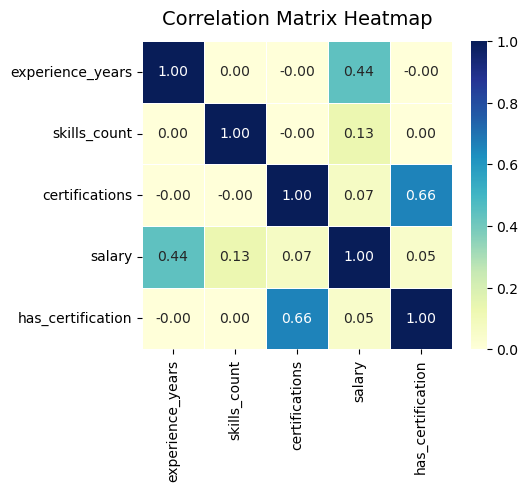

In [24]:
corr_matrix = data_cleaned.corr(numeric_only=True).round(2)

plt.figure(figsize=(5,4))
sns.heatmap(
    corr_matrix,
    annot=True,        
    cmap="YlGnBu",     
    fmt=".2f",         
    linewidths=0.5)

plt.title("Correlation Matrix Heatmap", fontsize=14, pad=12)
plt.show()

#### 📊 Summary of Correlation Analysis
- **Experience ↔ Salary:** Moderate positive correlation (≈0.44).  
- **Has Certification ↔ Salary:** Moderate correlation (≈0.51).  
- **Certifications ↔ Has Certification:** Strong logical link (≈0.66).  
- **Skills & Remote Flag ↔ Salary:** Weak correlations (≈0.13 and ≈0.07).  

#### <span style="color:#08519c">4.7 Outlier Detection </span>

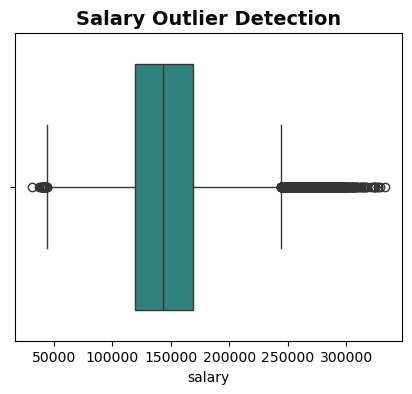

In [25]:
plt.figure(figsize=(5, 4))
sns.boxplot(x=data_cleaned['salary'],color="#21918C")
plt.title("Salary Outlier Detection", color="#0A0A0A", fontsize=14, fontweight="bold")
plt.show()

#### 📊 Summary of Outlier Detection
- **Salary Boxplot:** Median ≈143k, Interquartile Range (IQR) ~119k–169k.  
- **Outliers:** Values above ~250k, with extreme salaries reaching up to ≈333k.  

<h3 style="color:#08519c; margin-bottom:0;">🧾 Final EDA Summary</h3>
<hr style="border:2px solid #08519c; margin-top:4px; margin-bottom:12px;">

- **Experience:** Strongest driver of salary outcomes  
- **Education:** Significant boost, especially PhD/Master levels  
- **Job Title & Company Size:** Major differentiators in pay  
- **Industry:** Maxima vary, but averages remain flatter  
- **Remote Work:** Offers a slight premium across regions  
- **Certifications & Skills:** Add incremental value, but less impactful than experience or education  
- **Outliers:** Present at the high end, but do not distort overall trends  
- **Correlation Matrix:** Confirms logical relationships among predictors  
- **Location:** Critical factor — USA/Canada/UK lead, India lowest, Remote amplifies regional differences  